# 4D Coil Sketching: Example code to test different regularizations

Install environment first to use using the instructions in README.md.

WARNING: This is the pre-release version. The clean version is in progress.

# Setup and data loading


/home/plummerjw/miniforge3/envs/coil-sketching-4d/lib/python3.13/site-packages/sigpy/config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
No module named 'cupyx.cudnn'
  warnings.warn(


Phases: 6; Coils: 15; Excitations: 8339; Samples: 2750
Subsetting first 100.0% nf_e
SUBSAMPLED: Phases: 6; Coils: 15; Excitations: 8339; Samples: 2749
Affine transformation matrix used for saving this data: 
[[0 1 0 0]
 [0 0 1 0]
 [1 0 0 0]
 [0 0 0 1]]


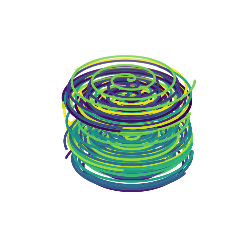

In [ ]:
import os
import sys
sys.path.append('../src')
sys.path.append('../sigpy_mod')  # Add the subdirectory to Python path
import numpy as np
import matplotlib.pyplot as plt
import sigpy      as sp
import sigpy.mri  as mr
import sigpy.plot as pl
from utils import *
import nibabel as nib
from monitor_gpu import monitor_gpu_memory  # GPU monitoring

# Setup
devnum = 0 # Device to use, set to -1 if running in CPU
toeplitz=False # Use Toeplitz to speed up A.N evaluations (i.e. the normal linear operator)
compress = True # Use SVD coil compression to compress and reorder data according to coil energy contribution
combine_csm = True # If you want to calculate 1 CSM from all combined data # Recommended to reduce memory, especially if using Toeplitz
espirit_csm = True # Use ESPIRIT instead of JSENSE (0.55T MRI data seemed to perform more reliably with ESPIRIT, but JSENSE is still a good option)
# Note: if espirit_csm is False, recon will use JSENSE. JSENSE requires installation of cudnn. This can be achieved using the terminal or manually in Python. Contact joseph.plummer@nih.gov for help.

# Number of sketched coils (including the constant non-sketched coils)
nch = 3 
number_non_sketched_coils = nch-1 

# Additional parameters
R = 1 # Throw away some data if attempting a faster reconstruction R>=1.
lamda = 0.1 # Recommended 0.001 to 1.
scale = 1 # Intensity scale the images by this factor.
coil_percentile = 100 # Keep only the top X% of coils by energy, e.g. 100 means all coils are kept, 50 means only the top 50% of coils are kept.

# List of recons
nufft=True
cg_sense = True
pdhg_sense = True
gm_sense = True
wavelet = True
tv = True
lor = True
mocolor = True
llor = True
mocolor_pdhg = True
mocollr_pdhg = True
mocolor_gm = True

# Device configuration
try:
    device = sp.Device(devnum)
except:
    print("Original devnum failed, using devnum 0 instead.")
    devnum=0
    device = sp.Device(devnum)
xp     = device.xp
device.use()
mvd = lambda x: sp.to_device(x, devnum)
mvc = lambda x: sp.to_device(x, sp.cpu_device)

# Load data
folder = '../data/lam-6bin/'
res_scale = 1
matrix_e =  (288+(1*32),288+(1*32),128)
matrix_r = tuple(int(dim * res_scale) for dim in matrix_e)
matrix_c = tuple(int(dim * res_scale) for dim in (288, 288, 112))  # Cropped image size
matrix_a = tuple(int(dim) for dim in (288, 288, 128))  # For density compensation
matrix_i = (288, 288)
ksp = np.load(folder + "bksp.npy")
coord = np.load(folder + "bcoord.npy")
coord[...,0] = coord[...,0]*matrix_e[0]
coord[...,1] = coord[...,1]*matrix_e[1]
coord[...,2] = coord[...,2]*matrix_e[2]
[nphase, nc0, nviews0, nread] = ksp.shape
print(f'Phases: {nphase}; Coils: {nc0}; Excitations: {nviews0}; Samples: {nread}')    

# Undersample spirals
nviews = int(nviews0/R)
ksp = ksp[...,:nviews,:]
coord = coord[:,:nviews,...] 

# Make a new folder to store the lamda value
if not os.path.exists(folder + f"/lamda_{lamda:.2e}"):
    os.makedirs(folder + f"/lamda_{lamda:.2e}/")
folder = folder + f"/lamda_{lamda:.2e}/"

# Undersample sample points along readout if res_scale < 1
nf_arr = np.sqrt(np.sum(coord[0, 0, :, :]**2, axis=1)) 
nf_e = np.sum(nf_arr < np.max(nf_arr)*res_scale)
print(f"Subsetting first {100*res_scale:.1f}% nf_e") # Note, this is not robust for VDS where the edges are more sampled than center
ksp = ksp[...,:nf_e]
coord = coord[...,:nf_e,:]
[nphase, nc, nviews, nread] = ksp.shape
print(f'SUBSAMPLED: Phases: {nphase}; Coils: {nc}; Excitations: {nviews}; Samples: {nread}') 

# Check whether a specified save data path exists
results_exist = os.path.exists(folder + "/sketching/png")

# Create a new directory because the results path does not exist
if not results_exist:
    os.makedirs(folder + "/sketching/png")
    print("A new directory inside: " + folder +
            " called 'sketching/png' has been created.")

# Save images as Nifti files
# Custom affine for coronally acquired images
aff = np.array([[0, 1, 0, 0],
                [0, 0, 1, 0],
                [1, 0, 0, 0],
                [0, 0, 0, 1]])
print("Affine transformation matrix used for saving this data: ")
print(str(aff))

# View coords
plt.figure(figsize=(3, 3), dpi=100)
ax = plt.axes(projection='3d')
N_visual = nviews//200  # Number of projections you want to show, inefficient for large n
color = iter(plt.cm.viridis(np.linspace(0, 1, N_visual)))
for i in np.linspace(0, nviews-1, N_visual):
    i = int(i)
    c = next(color)
    ax.scatter(coord[0, i, :, 0], coord[0, i, :, 1],
               coord[0, i, :, 2], color=c, s=0.5, marker='.')
ax.set_zlabel('$k_z$')
ax.set_ylabel('$k_y$')
ax.set_xlabel('$k_x$')
plt.axis("off")
# plt.savefig("coord.png", transparent=True, bbox_inches='tight', pad_inches=0)
plt.show()

def normalize(img, percentile=90):
    img_n = img/np.percentile(img.ravel(), percentile)
    return img_n

## OPTIONAL: apply a Hanning filter to raw k-space data to reduce high frequency noise (slow, can be made faster using GPU)



In [2]:
from scipy.signal.windows import tukey
ksp_filter_3d = False

def apply_tukey_filter(ksp, coords, tukey_alpha=0.2):
    """
    Applies a Tukey filter to k-space data based on the spatial location in kx, ky, kz.

    Parameters:
        ksp (np.ndarray): K-space data of shape (nc, nexc, nread).
        coords (np.ndarray): Coordinates of k-space samples of shape (nexc, nread, 3).
        tukey_alpha (float): Alpha parameter for the Tukey filter (0 = rectangular, 1 = Hann).

    Returns:
        np.ndarray: Filtered k-space data of the same shape as input ksp.
    """
    # Initialize filtered k-space array
    filtered_ksp = np.copy(ksp)

    # Find the max range in each dimension for normalization
    max_kx, max_ky, max_kz = np.max(np.abs(coords[..., 0])), np.max(np.abs(coords[..., 1])), np.max(np.abs(coords[..., 2]))
    
    # Create Tukey windows in each k-space dimension
    tukey_kx = tukey(len(np.unique(coords[..., 0])), tukey_alpha)
    tukey_ky = tukey(len(np.unique(coords[..., 1])), tukey_alpha)
    tukey_kz = tukey(len(np.unique(coords[..., 2])), tukey_alpha)
    
    # Normalize coordinates to index ranges in each dimension
    for i in range(coords.shape[0]):
        for j in range(coords.shape[1]):
            # Normalize kx, ky, kz to indices in Tukey windows
            idx_kx = int(((coords[i, j, 0] / max_kx) + 1) / 2 * (len(tukey_kx) - 1))
            idx_ky = int(((coords[i, j, 1] / max_ky) + 1) / 2 * (len(tukey_ky) - 1))
            idx_kz = int(((coords[i, j, 2] / max_kz) + 1) / 2 * (len(tukey_kz) - 1))
            
            # Apply the Tukey filter to the corresponding k-space point
            filter_value = tukey_kx[idx_kx] * tukey_ky[idx_ky] * tukey_kz[idx_kz]
            filtered_ksp[:, i, j] *= filter_value

    return filtered_ksp

if ksp_filter_3d:
    for i in range(nphase):
        ksp[i, ...] = apply_tukey_filter(ksp[i,...], coord[i, ...], tukey_alpha=0.1)
        print(f'3D Tukey filter applied to phase {i}.')


## Estimate k-space preconditioner

Calculating preconditioner...
dens.shape: (6, 1, 8339, 2749)


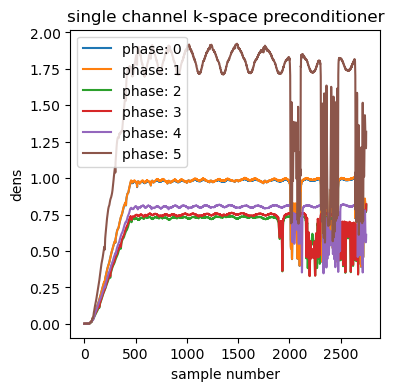

In [3]:
# Estimate k-space preconditioner
print("Calculating preconditioner...")
dens = np.zeros((nphase, 1, nviews, nread))
use_dcf = False # Use Pipe-Menon density compensation function instead of preconditioning (not as robust as preconditioning, but may offer prettier images)
t2star_weighting = False # Additional T2* weighting to the density compensation function
for resp in range(nphase):
    if use_dcf:
        dens[resp,0,...] = mvc(mr.pipe_menon_dcf(coord[resp,...], matrix_a, device=device, max_iter=30))
        
        # Multiply by a Tukey window to reduce high frequency noise
        from scipy.signal.windows import tukey
        tukey_window = tukey(2*nread, alpha=0.1)  # Alpha is the shape parameter for Tukey
        dens_weighting = tukey_window[nread:]
        dens[resp,0,...] *= dens_weighting

    else:
        # Precondition using Frank Ong's convex optimization problem 
        mps_precond = np.ones((1,) + matrix_a) # TODO: decide on the correct matrix size to use here
        mps_precond /= len(mps_precond)**0.5
        dens[resp,0,...] = mvc(mr.kspace_precond(
                            mps_precond,
                            coord=sp.to_device(coord[resp,...], device),
                            device=sp.Device(device), lamda=1e-2, oversamp=1.5))
        
    if t2star_weighting:
        # Estimate T2* decay	
        t2_star = 9  # ms # Assumed for 0.55T MRI data, adjust as needed	
        readout = 5 # ms	
        dwell_time = readout/nread	
        relaxation = np.zeros((nread,))	
        for jj in range(nread):	
            relaxation[jj] = np.exp(-(jj*dwell_time)/t2_star)**0.5
        dens[resp,0,:,:] *= relaxation
print(f"dens.shape: {dens.shape}")

# Normalize all to the same relative intensity
dens /= np.median(dens) 

# Plot
fig, (ax1) = plt.subplots(
    1, figsize=(4, 4), dpi=100)
for resp in range(nphase):
    ax1.plot(np.arange(nread), dens[resp, 0, 0,:], label=f'phase: {resp}') 
ax1.set_ylabel('dens')
if use_dcf:
    ax1.set_title("Pipe-Menon density compensation")
else:
    ax1.set_title("single channel k-space preconditioner")
ax1.set_xlabel("sample number")
plt.legend()
plt.show()

Running coil compression on all data combined into one array...
ksp.shape before coil compression: (6, 15, 8339, 2749)


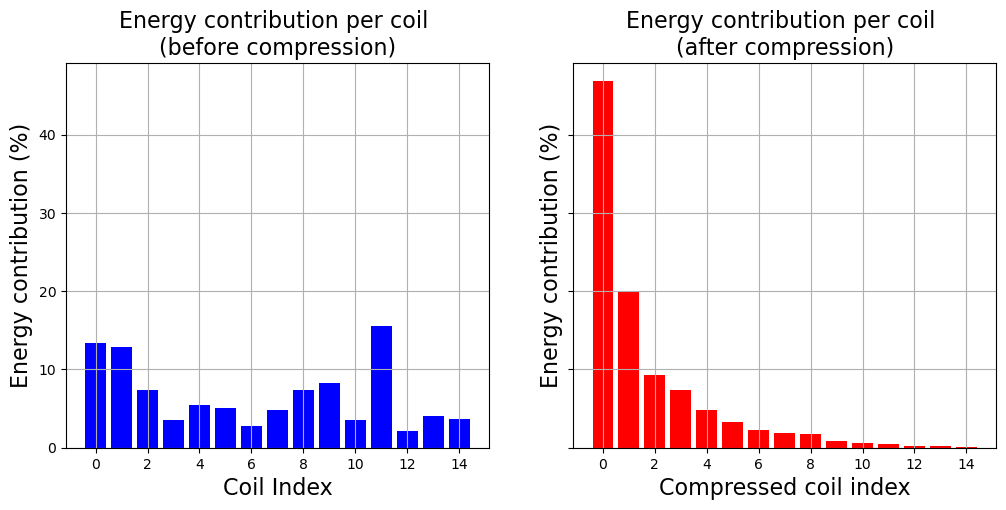

Percent energy per coil: [46.87 19.89  9.25  7.35  4.82  3.26  2.29  1.86  1.81  0.92  0.61  0.46
  0.26  0.23  0.12]
15 coils contain 100% of the total energy (for reference only).
eigenvalues[...,-4,-3,-2,-1] following coil-compression: ...[1.24951814e+09 7.05220813e+08 6.10665774e+08 3.18750297e+08]
LARGE COIL COMPRESSING TO 15 COILS


In [4]:
# Coil compression steps
if compress:
    if combine_csm: # WARNING: may not work as well if lots of excitations shared
        nc0 = ksp.shape[1]
        print("Running coil compression on all data combined into one array...")
        ksp_full = np.zeros((nc0,nphase*nviews,nread), dtype=complex)
        for coil in range(nc0): # Run through each coil individually
            # TODO: remove duplicate rows
            ksp_full[coil, ...] = ksp[:,coil,...].reshape((nphase*nviews,nread))
        ksp_full = mvd(ksp_full)
        print(f"ksp.shape before coil compression: {ksp.shape}")
        ksp_full, eigenvalues, nc = coil_compression(ksp_full, percentile=coil_percentile)
        ksp_full = mvc(ksp_full)
        for coil in range(nc0): # Run through each coil individually
            ksp[:,coil, ...] = ksp_full[coil,...].reshape((nphase, nviews,nread))
        print(f"eigenvalues[...,-4,-3,-2,-1] following coil-compression: ...{eigenvalues[-4:]}")
        ksp = mvc(ksp)
        del ksp_full
        del coil_compression
    else:       
        print("Running coil compression on each respiratory frame...")
        ksp = mvd(ksp[:,:,:nviews,...])
        print(f"ksp.shape before coil compression: {ksp.shape}")
        for resp in range(nphase):
            ksp[resp,...], eigenvalues, nc = coil_compression(ksp[resp,...], percentile=coil_percentile)
            print(f"phase {resp}: eigenvalues[...,-4,-3,-2,-1] following coil-compression: ...{eigenvalues[-4:]}")
        ksp = mvc(ksp)
        
if compress:
    if nc0 == 15:
        print(f"LARGE COIL COMPRESSING TO {nc} COILS")
        nc = nc
    elif nc0 == 21:
        nc = nc # 18
        print(f"MEDIUM COIL COMPRESSING TO {nc} COILS")
                
    if 'pdw' in folder:
        nc = nc0
        print("NOT REDUCING COILS AS PDW IMAGE AND AIMING TO MAXIMIZE SIGNAL")


# Subsample coil channels and declare variables
ksp_us = ksp[:,:nc,:nviews,...] 
coord_us = coord[:,:nviews,...] 
dens_us = dens[:,:,:nviews,...]
del(ksp)


In [5]:
print("Calculating csm...")
mps = np.zeros([nphase] + [nc] + list(matrix_r), dtype=complex)
if combine_csm == False:
    for resp in range(nphase):
        mps[resp,...] = mvc(sp.mri.app.JsenseRecon(ksp_us[resp,:nc,...], 
                                                coord=coord_us[resp,...],
                                                weights=dens_us[resp,0,...], # TODO: decide if helpful
                                                mps_ker_width=8-3, # Smaller leads to lower res mps, but maybe good if smoothing over lungs
                                                ksp_calib_width=24-4, 
                                                lamda=1e-2,
                                                img_shape=matrix_r, 
                                                device=device, 
                                                max_iter=30, 
                                                max_inner_iter=20, 
                                                show_pbar=True).run())
        # mps[resp,...] = mps_precond

    sp.plot.ImagePlot(mps[resp], x=1, y=2, z=0,
                                title=f"[MAG] Sensitivity maps estimated with J-SENSE NLINV for respiratory phase {resp}", colormap='gray', mode='m')
    sp.plot.ImagePlot(mps[resp], x=1, y=2, z=0,
                                title=f"[PHASE] Sensitivity maps estimated with J-SENSE NLINV for respiratory phase {resp}", colormap='hsv', mode='p')


    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(mps[0,...], 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/csm_phase_0')

    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

Calculating csm...


## Attempt to calculate CSM using JSENSE (Cartesian) or ESPIRIT

In [6]:
sys.path.append('../sigpy_mod')
import csm
import importlib
importlib.reload(csm)
if combine_csm is False:
    if espirit_csm:

        print("Calculating csm...")
        mps_jsense = np.zeros([nphase] + [nc] + list(matrix_r), dtype=complex)
        mps_espirit = np.zeros([nphase] + [nc] + list(matrix_r), dtype=complex)
        for resp in range(nphase):
            mps_jsense[resp,...] = csm.jsense_csm(ksp_us[resp,:nc,...], coord_us[resp,...], dens_us[resp,0,...], matrix_r, device,
                                            mps_ker_width=5,
                                            ksp_calib_width=24,
                                            lamda=1e-4,)
            mps_espirit[resp,...] = csm.espirit_csm(ksp_us[resp,:nc,...], coord_us[resp,...], dens_us[resp,0,...], matrix_r, device, 
                            crop=0,
                            thresh=0.02,
                                kernel_width=6,
                                calib_width=24,
                                max_iter=100).get()
            
        sp.plot.ImagePlot(mps_jsense[resp,...], x=1, y=2, z=0,
                                    title=f"MPS jsense respiratory phase {resp}", colormap='gray', mode='m')
        sp.plot.ImagePlot(mps_jsense[resp,...], x=1, y=2, z=0,
                                    title=f"MPS jsense respiratory phase {resp}", colormap='hsv', mode='p')
        sp.plot.ImagePlot(mps_espirit[resp,...], x=1, y=2, z=0,
                                    title=f"[MAG] MPS espirit respiratory phase {resp}", colormap='gray', mode='m')    
        sp.plot.ImagePlot(mps_espirit[resp,...], x=1, y=2, z=0,
                                    title=f"[PHASE] MPS espirit respiratory phase {resp}", colormap='hsv', mode='p')


        # FORCEFULLY OVERWRITE MPS WITH OUR NEW ONE
        # mps = mps_jsense
        mps = mps_espirit
        del mps_espirit, mps_jsense

        import cupy as cp
        cp._default_memory_pool.free_all_blocks()


        # rss = np.linalg.norm(mps[resp, :,...], axis=0) 

        # sp.plot.ImagePlot(rss, x=1, y=2, z=0,
        #                             title=f"rss", colormap='gray', mode='m')

In [ ]:
if combine_csm:
    importlib.reload(csm)
    print("Calculating csm for all phases combined together (with dcf)...")
    ksp_full = np.zeros((nc,nphase*nviews,nread), dtype=complex)
    for coil in range(nc): # Run through each phase individually
        ksp_full[coil, ...] = ksp_us[:,coil,...].reshape((nphase*nviews,nread))
    coord_full = coord_us.reshape((nphase*nviews,nread, 3))
    
    if espirit_csm:
        dens_full = mvc(mr.pipe_menon_dcf(coord_full, matrix_a, device=device, max_iter=30, width=3.5, beta=8))
        tukey_window = tukey(2*nread, alpha=0.1)  # Alpha is the shape parameter for Tukey
        dens_weighting = tukey_window[nread:]
        dens_full *= dens_weighting
        mps_full = csm.espirit_csm(ksp_full, coord_full, dens_full, matrix_r, device, 
                        crop=0,
                        thresh=0.02,
                            kernel_width=6,
                            calib_width=24-4,
                            max_iter=100,
                            downscale_factor=2).get()
        sp.plot.ImagePlot(mps_full, x=1, y=2, z=0,
                                title=f"[MAG] Sensitivity maps estimated with ESPIRIT for ALL phases", colormap='gray', mode='m',vmax=1)
        sp.plot.ImagePlot(mps_full, x=1, y=2, z=0,
                                    title=f"[PHASE] Sensitivity maps estimated with ESPIRIT for ALL phases", colormap='hsv', mode='p')
        sp.plot.ImagePlot(mps_full-mps[resp], x=1, y=2, z=0,
                                    title=f"[MAG] Sensitivity maps estimated with ESPIRIT (DIFFERENCE)", colormap='gray', mode='m', vmax=0.2)
        
    else:
        mps_precond = np.ones((1,) + matrix_a) # TODO: decide on the correct matrix size to use here
        mps_precond /= len(mps_precond)**0.5
        dens_full = mvc(mr.kspace_precond(
                                    mps_precond,
                                    coord=sp.to_device(coord_full[...], device),
                                    device=sp.Device(device), lamda=1e-2, oversamp=1.5))[0,...]
        mps_full = mvc(sp.mri.app.JsenseRecon(ksp_full, 
                                            coord=coord_full, 
                                            weights=dens_full, 
                                            mps_ker_width=8-3, 
                                            ksp_calib_width=24-4, 
                                            lamda=1e-2,
                                            img_shape=matrix_r, 
                                            device=device, 
                                            max_iter=30,
                                            max_inner_iter=20, 
                                            show_pbar=True).run())
        sp.plot.ImagePlot(mps_full, x=1, y=2, z=0,
                                title=f"[MAG] Sensitivity maps estimated with J-SENSE NLINV for ALL phases", colormap='gray', mode='m',vmax=1)
        sp.plot.ImagePlot(mps_full, x=1, y=2, z=0,
                                    title=f"[PHASE] Sensitivity maps estimated with J-SENSE NLINV for ALL phases", colormap='hsv', mode='p')
        sp.plot.ImagePlot(mps_full-mps[resp], x=1, y=2, z=0,
                                    title=f"[MAG] Sensitivity maps estimated with J-SENSE NLINV (DIFFERENCE)", colormap='gray', mode='m', vmax=0.2)
    del(ksp_full, coord_full, dens_full)



    for resp in range(nphase):
        mps[resp,...] = mps_full
        print("Overwriting sensitivity map with the full map.")
        
    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(mps[0,...], 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/csm_phase_combined')
        
import cupy as cp
cp._default_memory_pool.free_all_blocks()

Calculating csm for all phases combined together (with dcf)...


PipeMenonDCF:   0%|          | 0/30 [00:00<?, ?it/s]

## Let's do some linear algebra 

In [ ]:
print(f'ksp_us.shape: {ksp_us.shape}')
print(f'coord_us.shape: {coord_us.shape}')
print(f'dens_us.shape: {dens_us.shape}')
print(f'mps.shape: {mps.shape}')
print(ksp_us[0,...].shape[:-3])

# 4D NUFFT
F = sp.linop.NUFFT(ishape=(nc,) + matrix_r,
                coord=coord_us[0,...])
print("done")
S = sp.linop.Multiply(ishape = (nc,) + matrix_r, # Keep the channel as the ishape to ensure the output image is multiple channels
                    mult=mps[0,...])
print("done")
D = sp.linop.Multiply(F.oshape, dens_us[0,...])
print("done")
A_us = D * F * S
print("done")

y = ksp_us[0,...]
y = sp.to_device(y, 1)
img_us = mvc(A_us.H(y))
y = sp.to_device(y, sp.cpu_device)
del y
scale = np.percentile(np.abs(img_us.flatten()), 95)
vmax = np.percentile(np.abs(img_us.flatten()), 99)
print(r'shape of reconstructed image using $A^H y$' + f' is: {img_us.shape}')
pl.ImagePlot(img_us, x=1, y=2, z=0,vmax=vmax, title="Single respiratory frame inverse NUFFT", colormap="gray")
del(F,S,D,A_us)     

import cupy as cp
cp._default_memory_pool.free_all_blocks()

## Let's solve using the appended NUFFT method, this time using the more robust NUFFT

In [ ]:
if nufft:
    sys.path.append('../sigpy_mod')
    import custom_linop
    import importlib
    importlib.reload(custom_linop)

    # TODO: incorporate class system like sp.linop to allow A(x) instead of A*x
    # Try using append method
    As = []
    nphase=6
    for resp in range(nphase):
        F = custom_linop.NFT(ishape=(nc,) + matrix_r,
                        coord=coord_us[resp,...],
                        device=sp.Device(devnum),
                        )
        print(f'F.oshape = {F.oshape}')
        S = sp.linop.Multiply(ishape = (nc,) + matrix_r, # Keep the channel as the ishape to ensure the output image is multiple channels
                            mult=mps[resp,...])
        D = sp.linop.Multiply(F.oshape, dens_us[resp,...]) # Note that the **0.5 is not used here as it's just an inverse nufft, and ksp has not been multiplied
        A = D * F * S
        As.append(A)
        print(f"resp = {resp}")
    As = custom_linop.Diags(As, 
                    oshape=(nphase, nc, nviews, nread,),
                    ishape=(nphase,)+ matrix_r)
    print(f'As.oshape = {As.oshape}')
    print(f'ksp_us.shape: {ksp_us.shape}')
    print('done')
    y = mvd(ksp_us[...])
    img_us = mvc(As.H(y))
    del y
    print(r'shape of reconstructed image using $A^H y$' + f' is: {img_us.shape}')  
    pl.ImagePlot(img_us, x=1, y=2, z=0,title="Multiple respiratory frame inverse NUFFT", colormap="gray")

    test_normal = False
    if test_normal:
        import time
        img_us = mvd(img_us)
        start_time = time.time()  # Start time
        test = As.N(img_us)
        end_time = time.time()  # End time
        print(f"Execution time: {end_time - start_time:.4f} seconds")

        import time
        start_time = time.time()  # Start time
        test = As.H * As * (img_us)
        end_time = time.time()  # End time
        print(f"Execution time: {end_time - start_time:.4f} seconds")

    F = None
    D = None
    S = None
    A = None
    As = None
    y = None
    del(F,A,S,D,As)

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_us, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_inverse_nufft')
    

    


In [ ]:
import gc
gc.collect()

import torch
import importlib

# Get memory usage in MB
print(f"Allocated memory: {torch.cuda.memory_allocated() / 1024 ** 2} MB")
print(f"Cached memory: {torch.cuda.memory_reserved() / 1024 ** 2} MB")

import cupy as cp

# Get memory usage statistics
mempool = cp.get_default_memory_pool()
pinned_mempool = cp.get_default_pinned_memory_pool()

print(f"Used memory: {mempool.used_bytes() / 1024 ** 2} MB")
print(f"Total memory: {mempool.total_bytes() / 1024 ** 2} MB")

# To free unused memory
mempool.free_all_blocks()

# Optionally clear any pinned memory (CPU-GPU pinned transfers)
pinned_mempool.free_all_blocks()

# Clear variables stored on GPU 
cp._default_memory_pool.free_all_blocks()

# Avoiding Device Synchronization for Faster Execution
# By default, many CuPy operations perform implicit device synchronization (waiting for all 
# previous operations to complete before continuing). You can explicitly manage synchronization 
# to improve performance by deferring synchronization calls:
cp.cuda.stream.get_current_stream().synchronize()  # Manually synchronize


print(f"Used memory: {mempool.used_bytes() / 1024 ** 2} MB")
print(f"Total memory: {mempool.total_bytes() / 1024 ** 2} MB")


In [ ]:
import importlib

# Reload cupy to see if that is where the memory dump is located
importlib.reload(cp)
importlib.reload(sp)
importlib.reload(mr)
import time
time.sleep(10) # Wait a second to give it time to clear memory if not done already 

print(f"Used memory: {mempool.used_bytes() / 1024 ** 2} MB")
print(f"Total memory: {mempool.total_bytes() / 1024 ** 2} MB")



## Let's try a sketched recon using our 4D $A$ operator

In [ ]:
import sketching_4d_app as sk4d
import importlib
importlib.reload(sk4d)
importlib.reload(sp)

# Coil sketching reconstruction
max_init_iter = 4 # Works better for compressed coils as initial iters are higher energy
max_inner_iter = 5
max_outer_iter = 6 
# nch = 3 # Paper recommends 3-4, but shows improvement up to 6
# number_non_sketched_coils = 0 # If None, defaults to nch - 1 inside the app. If nch is high (6+), can get away with using 0 sketched coils
np.random.seed(1)

# Clear variables stored on GPU 
import cupy as cp
cp._default_memory_pool.free_all_blocks()


## Combine sensitivity maps into one (if chosen)

In [ ]:
if combine_csm and len(mps.shape) == 5:
    mps = mvc(mps)[0,...]
else:
    mps = mvc(mps)

## CG-SENSE reconstruction



In [ ]:
save_objective_values=False

if cg_sense:
    # Move variables to cpu to free up space
    ksp_us = mvc(ksp_us)
    coord_us = mvc(coord_us)
    dens_us = mvc(dens_us)

        
    import sketching_4d_app as sk4d
    import sketching_app
    importlib.reload(sketching_app)
    import importlib
    importlib.reload(sk4d)
    importlib.reload(sp)
    sys.path.append('../sigpy_mod')
    import custom_linop
    import importlib
    importlib.reload(custom_linop)
    import maxeig as me
    importlib.reload(me)
    
    # Start monitoring
    print("MONITORING GPU USAGE...")
    tic, toc, memory_usage_sketched, shutdown = monitor_gpu_memory(gpu_index=devnum)
    tic()
    
    if save_objective_values:
        ksp_us = mvd(ksp_us)
        dens_us = mvd(dens_us)
    sketched_cg_solver = sk4d.SketchedSenseRecon(ksp_us/scale, # TODO: test with/without scale factor as it might be altering the balance in the DC part of obj func  -result: remove scale!!
                                                mps=mps, 
                                                lamda=lamda*1e3, # TODO: get it to work with extremely little regularization, then go from there
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    solver='ConjugateGradient',
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum), # Must be same device as ksp and dcf 
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30, # Not used for conjugate gradient 
                                    save_objective_values=save_objective_values, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    )
    
    img_sk_cg_sense = mvc(scale*sketched_cg_solver.run())
    if save_objective_values:
        sketched_cg_sense_objective = np.array(sketched_cg_solver.objective_values)
    del sketched_cg_solver
    
    sketched_memory_cg = np.array(memory_usage_sketched)*1e-3
    toc()
    # Plot results
    plt.figure(figsize=(3,4))
    plt.plot(memory_usage_sketched)
    plt.xlabel('time')
    plt.ylabel('memory usage (MB)')
    plt.grid(True)
    plt.show()
    shutdown()
    print("GPU MONITORING COMPLETE.")
        
    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_cg_sense, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_cg_sense')

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_cg_sense.ravel()), 95)
    pl.ImagePlot(img_sk_cg_sense[0,...], 
                x=1, y=3,
                title="Under-sampled Sketching Reconstruction (CG SENSE)", 
                colormap="gray", 
                vmax=vmax,
                )
    
    pl.ImagePlot(img_sk_cg_sense[0,...], 
                x=1, y=3, mode='p',
                title="PHASE Under-sampled Sketching Reconstruction (CG SENSE)", 
                colormap="jet", 
                )
    
    # Get memory usage statistics
    mempool = cp.get_default_memory_pool()
    pinned_mempool = cp.get_default_pinned_memory_pool()
    mempool.free_all_blocks()
    pinned_mempool.free_all_blocks()
    cp._default_memory_pool.free_all_blocks()
    cp.cuda.stream.get_current_stream().synchronize() 
    
    # Display sagittal slices from insp/exp phases
    print(f"Sketched reconstruction with {nch} coils:")
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))  # wider to accommodate two images side-by-side
    sag_slice = 6* matrix_c[0] // 10
    img_tmp = crop_center(np.moveaxis(img_sk_cg_sense, 0, -1),(matrix_c[0], matrix_c[1], int(res_scale*matrix_e[2])))
    img_insp = np.rot90(normalize(abs(img_tmp[..., nphase//2])), k=1)  
    img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)
    sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
    sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)
    concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
    im = ax.imshow(concat_img, cmap='gray', vmax=1)
    ax.axis('off')
    fig.savefig(folder + f'/sketching/png/sketched_img_{nch}_coils_cg_sense.png', bbox_inches='tight', pad_inches=0)
    plt.show()
    
    
    
    
    # Start monitoring
    # print("MONITORING GPU USAGE...")
    # tic, toc, memory_usage_non_sketched, shutdown = monitor_gpu_memory(gpu_index=devnum)
    # tic()
    # if save_objective_values:
    #     ksp_us = mvd(ksp_us)
    #     dens_us = dens_us  
    # cg_solver = sk4d.SketchedSenseRecon(ksp_us/scale, # TODO: test with/without scale factor as it might be altering the balance in the DC part of obj func  -result: remove scale!!
    #                                             mps=mps, 
    #                                             lamda=lamda*1e3, # TODO: get it to work with extremely little regularization, then go from there
    #                                             reduced_ncoils=nc,
    #                                 weights=dens_us, 
    #                                 coord=coord_us,
    #                                 solver='ConjugateGradient',
    #                                 toeplitz=toeplitz,
    #                                 show_pbar=True, device=sp.Device(devnum), # Must be same device as ksp and dcf 
    #                                 number_non_sketched_coils=nc-1, # None = Defaults to nch-1 
    #                                 max_init_iter=max_init_iter + (max_outer_iter*(max_inner_iter-1)),
    #                                 max_outer_iter=0,
    #                                 max_inner_iter=0,
    #                                 max_power_iter=30, # Not used for conjugate gradient 
    #                                 save_objective_values=save_objective_values, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
    #                                 coil_batch_size=nc,
    #                                 )
    # img_cg_sense = mvc(scale*cg_solver.run())
    # if save_objective_values:
    #     cg_sense_objective = np.array(cg_solver.objective_values)
    # del cg_solver
    
    # toc()
    

    # # Plot results
    # plt.figure(figsize=(3,4))
    # plt.plot(memory_usage_non_sketched)
    # plt.xlabel('time')
    # plt.ylabel('memory usage (MB)')
    # plt.grid(True)
    # plt.show()
    # shutdown()
    # print("GPU MONITORING COMPLETE.")
    
    # ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_cg_sense, 0, -1)), matrix_c), affine=aff)
    # nib.save(ni_img, folder + '/sketching/img_cg_sense')

    # # Clear variables stored on GPU 
    # import cupy as cp
    # cp._default_memory_pool.free_all_blocks()

    # import sigpy.plot as pl
    # vmax = np.percentile(abs(img_cg_sense.ravel()), 95)
    # pl.ImagePlot(img_cg_sense[3,...], 
    #             x=1, y=3,
    #             title="Under-sampled Reconstruction (CG SENSE)", 
    #             colormap="gray", 
    #             vmax=vmax,
    #             )
    
    # Move variables to cpu to free up space
    ksp_us = mvc(ksp_us)
    coord_us = mvc(coord_us)
    dens_us = mvc(dens_us)
    


In [ ]:
if save_objective_values:
    plt.figure(figsize=(8, 5), dpi=150)  # Higher DPI for better resolution
    time_indices = np.arange(max_init_iter + (max_outer_iter*(max_inner_iter-1))+1)
    non_sketched_residual = abs(abs(cg_sense_objective)-cg_sense_objective[-1])/cg_sense_objective[-1]
    sketched_residual = abs(abs(sketched_cg_sense_objective)-sketched_cg_sense_objective[-1])/sketched_cg_sense_objective[-1]
    plt.semilogy(time_indices*200, non_sketched_residual, color='#FF5733', linewidth=4, label='Non-sketched')
    plt.semilogy(time_indices*60, sketched_residual, color='#2E86C1', linestyle='--', linewidth=4, label='Sketched')
    plt.xlim(0, 250)
    plt.ylim((1e-3,1e2))
    plt.xlabel('Time (s)', fontsize=20, fontweight='bold')
    plt.ylabel(r'$\left. ||x^t - x^{\infty}||_2^2 \middle/ ||x^{\infty}||_2^2 \right. \, $', fontsize=20, fontweight='bold')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=16, loc='upper right', frameon=False)
    plt.grid(color='gray', linestyle=':', linewidth=0.5)
    plt.tight_layout()  # Adjust layout for better fit
    plt.show()


In [ ]:
try:
    # Plot results
    sketched_memory = np.array(memory_usage_sketched)*1e-3
    non_sketched_memory = np.array(memory_usage_non_sketched)*1e-3


    plt.figure(figsize=(8, 5), dpi=150)  # Higher DPI for better resolution
    plt.plot(non_sketched_memory, color='#FF5733', linewidth=4, label='Non-sketched')  # Using a bold, distinct color
    plt.plot(sketched_memory, color='#2E86C1', linestyle='--', linewidth=4, label='Sketched')  # Dash style for contrast
    plt.xlim(0, 250)
    plt.ylim(0, max(max(non_sketched_memory), max(sketched_memory)) * 1.1)
    plt.xlabel('Time (s)', fontsize=20, fontweight='bold')
    plt.ylabel('Memory usage (GB)', fontsize=20, fontweight='bold')
    # plt.title('GPU Memory Usage Over Time', fontsize=22, fontweight='bold', pad=20)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(fontsize=16, loc='lower right', frameon=False)
    plt.grid(color='gray', linestyle=':', linewidth=0.5)
    plt.tight_layout()  # Adjust layout for better fit
    plt.show()
except:
    print("Could not plot memory plots.")


## $L_1$ wavelet transform regularized reconstruction using Gradient Method

In [ ]:
if wavelet:
    # Move variables to cpu to free up space
    ksp_us = mvc(ksp_us)
    coord_us = mvc(coord_us)
    dens_us = mvc(dens_us)
        
    import sketching_4d_app as sk4d
    import importlib
    importlib.reload(sk4d)
    importlib.reload(sp)
    sys.path.append('../sigpy_mod')
    import custom_linop
    import importlib
    importlib.reload(custom_linop)
    img_sk_wavelet = mvc(scale*sk4d.SketchedL1WaveletRecon4D(ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    solver='GradientMethod',
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum), # Must be same device as ksp and dcf 
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    coil_batch_size=nch).run())
    # img_sk = np.rot90(mvc(img_sk), k=-1)

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_wavelet, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_wavelet')

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()
    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_wavelet.ravel()), 95)
    pl.ImagePlot(img_sk_wavelet[3,...], 
                x=1, y=3,
                title="Under-sampled Sketching Reconstruction (Wavelet)", 
                colormap="gray", 
                vmax=vmax,
                )
    
    # Display sagittal slices from insp/exp phases
    print(f"Sketched reconstruction with {nch} coils:")
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))  # wider to accommodate two images side-by-side
    sag_slice = 6* matrix_c[0] // 10
    img_tmp = crop_center(np.moveaxis(img_sk_wavelet, 0, -1),(matrix_c[0], matrix_c[1], int(res_scale*matrix_e[2])))
    img_insp = np.rot90(normalize(abs(img_tmp[..., nphase//2])), k=1)  
    img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)
    sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
    sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)
    concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
    im = ax.imshow(concat_img, cmap='gray', vmax=1)
    ax.axis('off')
    fig.savefig(folder + f'/sketching/png/sketched_img_{nch}_coils_wavelet.png', bbox_inches='tight', pad_inches=0)
    plt.show()
    
    img_wavelet = mvc(scale*sk4d.SketchedL1WaveletRecon4D(ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nc,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    solver='GradientMethod',
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum), # Must be same device as ksp and dcf 
                                    number_non_sketched_coils=nc-1, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter + (max_outer_iter*(max_inner_iter-1)),
                                    max_outer_iter=0,
                                    max_inner_iter=0,
                                    max_power_iter=30,
                                    coil_batch_size=nc).run())
    # img_sk = np.rot90(mvc(img_sk), k=-1)

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_wavelet, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_wavelet')

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()
    import sigpy.plot as pl
    vmax = np.percentile(abs(img_wavelet.ravel()), 95)
    pl.ImagePlot(img_wavelet[3,...], 
                x=1, y=3,
                title="Under-sampled Reconstruction (Wavelet)", 
                colormap="gray", 
                vmax=vmax,
                )


## Total variation reconstruction (using PDHG)
Supposedly, this is faster than the gradient method used in the L1 wavelet recon.

Supposedly, it is also more robust to non-smooth regularizations such as the nuclear norm.

The motivation behind this approach is that we can leverage $G$ for the motion fields, and $proxg()$ for the nuclear norm proximal operator used in MoCoLoR.

In [ ]:
if tv:
    import sketching_4d_app as sk4d
    import importlib
    importlib.reload(sk4d)
    importlib.reload(sp)

    # # nch = 3 # Paper recommends 3-4, but shows improvement up to 6
    # # number_non_sketched_coils = 0 # If None, defaults to nch - 1 inside the app. If nch is high (6+), can get away with using 0 sketched coils
    # np.random.seed(1)

    # Change device to free up memory
    img_sk_tv = mvc(scale*sk4d.SketchedTotalVariationRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    solver='PrimalDualHybridGradient', # Default
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    # TODO: Add max_cg_iter to control the conj grad iteration count. Default 10
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_tv, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_tv')
    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()
    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_tv.ravel()), 95)
    pl.ImagePlot(img_sk_tv[3,...], 
                x=1, y=3,
                title="Under-sampled Sketching Reconstruction (TV)", 
                colormap="gray", 
                vmax=vmax
                )
    
    # Display sagittal slices from insp/exp phases
    print(f"Sketched reconstruction with {nch} coils:")
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))  # wider to accommodate two images side-by-side
    sag_slice = 6* matrix_c[0] // 10
    img_tmp = crop_center(np.moveaxis(img_sk_tv, 0, -1),(matrix_c[0], matrix_c[1], int(res_scale*matrix_e[2])))
    img_insp = np.rot90(normalize(abs(img_tmp[..., nphase//2])), k=1)  
    img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)
    sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
    sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)
    concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
    im = ax.imshow(concat_img, cmap='gray', vmax=1)
    ax.axis('off')
    fig.savefig(folder + f'/sketching/png/sketched_img_{nch}_coils_tv.png', bbox_inches='tight', pad_inches=0)
    plt.show()
    
    # img_tv = mvc(scale*sk4d.SketchedTotalVariationRecon4D(y=ksp_us/scale, 
    #                                             mps=mps, 
    #                                             lamda=lamda, 
    #                                             reduced_ncoils=nc,
    #                                 weights=dens_us, 
    #                                 coord=coord_us,
    #                                 solver='PrimalDualHybridGradient', # Default
    #                                 toeplitz=toeplitz,
    #                                 show_pbar=True, device=sp.Device(devnum),
    #                                 number_non_sketched_coils=nc-1, # None = Defaults to nch-1 
    #                                 max_init_iter=max_init_iter + ((max_inner_iter-1) * max_inner_iter),
    #                                 max_outer_iter=0,
    #                                 max_inner_iter=0,
    #                                 max_power_iter=30,
    #                                 # TODO: Add max_cg_iter to control the conj grad iteration count. Default 10
    #                                 save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
    #                                 coil_batch_size=nc,
    #                                 ).run())

    # ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_tv, 0, -1)), matrix_c), affine=aff)
    # nib.save(ni_img, folder + '/sketching/img_tv')
    # # Clear variables stored on GPU 
    # import cupy as cp
    # cp._default_memory_pool.free_all_blocks()
    # import sigpy.plot as pl
    # vmax = np.percentile(abs(img_tv.ravel()), 95)
    # pl.ImagePlot(img_tv[3,...], 
    #             x=1, y=3,
    #             title="Under-sampled Reconstruction (TV)", 
    #             colormap="gray", 
    #             vmax=vmax
    #             )

## Let's try a 4D Low Rank recon (without registration)

In [ ]:
if lor:
    import sketching_4d_app as sk4d
    import importlib
    importlib.reload(sk4d)
    importlib.reload(sp)
    import prox_lr
    importlib.reload(prox_lr)
    
    # Start monitoring
    print("MONITORING GPU USAGE...")
    tic, toc, memory_usage_sketched, shutdown = monitor_gpu_memory(gpu_index=devnum)
    tic()

    np.random.seed(1)
    img_sk_lr_no_moco = mvc(scale*sk4d.SketchedLowRankRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    moco=False,
                                    # solver='GradientMethod', # Default
                                    solver='PrimalDualHybridGradient', # Default
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_lr_no_moco, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_lr_no_moco')
    
    sketched_memory_lor = np.array(memory_usage_sketched)*1e-3
    toc()
    # Plot results
    plt.figure(figsize=(3,4))
    plt.plot(memory_usage_sketched)
    plt.xlabel('time')
    plt.ylabel('memory usage (MB)')
    plt.grid(True)
    plt.show()
    shutdown()
    print("GPU MONITORING COMPLETE.")

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_lr_no_moco.ravel()), 95)
    for resp in range(nphase):
        pl.ImagePlot(img_sk_lr_no_moco[resp,...], 
                    x=1, y=3,
                    title="Under-sampled Sketching Reconstruction (LR - no registration)", 
                    colormap="gray", 
                    vmax=vmax,
                    )
        
    # Display sagittal slices from insp/exp phases
    print(f"Sketched reconstruction with {nch} coils:")
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))  # wider to accommodate two images side-by-side
    sag_slice = 6* matrix_c[0] // 10
    img_tmp = crop_center(np.moveaxis(img_sk_lr_no_moco, 0, -1),(matrix_c[0], matrix_c[1], int(res_scale*matrix_e[2])))
    img_insp = np.rot90(normalize(abs(img_tmp[..., nphase//2])), k=1)  
    img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)
    sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
    sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)
    concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
    im = ax.imshow(concat_img, cmap='gray', vmax=1)
    ax.axis('off')
    fig.savefig(folder + f'/sketching/png/sketched_img_{nch}_coils_lr_no_moco.png', bbox_inches='tight', pad_inches=0)
    plt.show()
        
    # Start monitoring
    # print("MONITORING GPU USAGE...")
    # tic, toc, memory_usage_non_sketched, shutdown = monitor_gpu_memory(gpu_index=devnum)
    # tic()
        
    # img_lr_no_moco_gm = mvc(scale*sk4d.SketchedLowRankRecon4D(y=ksp_us/scale, 
    #                                             mps=mps, 
    #                                             lamda=lamda, 
    #                                             reduced_ncoils=nc,
    #                                 weights=dens_us, 
    #                                 coord=coord_us,
    #                                 moco=False,
    #                                 # solver='GradientMethod', # Default
    #                                 solver='PrimalDualHybridGradient', # Default
    #                                 toeplitz=toeplitz,
    #                                 show_pbar=True, device=sp.Device(devnum),
    #                                 number_non_sketched_coils=nc-1, # None = Defaults to nch-1 
    #                                 max_init_iter=max_init_iter + (max_outer_iter * (max_inner_iter-1)),
    #                                 max_outer_iter=0,
    #                                 max_inner_iter=0,
    #                                 max_power_iter=30,
    #                                 save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
    #                                 coil_batch_size=nc,
    #                                 ).run())

    # ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_lr_no_moco_gm, 0, -1)), matrix_c), affine=aff)
    # nib.save(ni_img, folder + '/sketching/img_lr_no_moco_gm')
    
    # toc()
    # # Plot results
    # plt.figure(figsize=(3,4))
    # plt.plot(memory_usage_non_sketched)
    # plt.xlabel('time')
    # plt.ylabel('memory usage (MB)')
    # plt.grid(True)
    # plt.show()
    # shutdown()
    # print("GPU MONITORING COMPLETE.")

    # # Clear variables stored on GPU 
    # import cupy as cp
    # cp._default_memory_pool.free_all_blocks()

    # import sigpy.plot as pl
    # vmax = np.percentile(abs(img_lr_no_moco_gm.ravel()), 95)
    # for resp in range(nphase):
    #     pl.ImagePlot(img_lr_no_moco_gm[resp,...], 
    #                 x=1, y=3,
    #                 title="Under-sampled Reconstruction (LR - no registration)", 
    #                 colormap="gray", 
    #                 vmax=vmax,
    #                 )

# Experimental: try my local-temporal low rank recon (with and without registration)

In [ ]:
if mocolor:
    import sketching_4d_app as sk4d
    import importlib
    importlib.reload(sk4d)
    importlib.reload(sp)
    import sketching_app
    importlib.reload(sketching_app)
    import prox_ltr
    importlib.reload(prox_ltr)
    import registration_oflow3D
    importlib.reload(registration_oflow3D)
    import opticalflow3D
    importlib.reload(opticalflow3D)
    
    # Get memory usage statistics
    mempool = cp.get_default_memory_pool()
    pinned_mempool = cp.get_default_pinned_memory_pool()
    mempool.free_all_blocks()
    pinned_mempool.free_all_blocks()
    cp._default_memory_pool.free_all_blocks()
    cp.cuda.stream.get_current_stream().synchronize() 
    
    # Start monitoring
    print("MONITORING GPU USAGE...")
    tic, toc, memory_usage_sketched, shutdown = monitor_gpu_memory(gpu_index=devnum)
    tic()

    np.random.seed(1)
    img_sk_lr_moco_jacobian = mvc(scale*sk4d.SketchedMotionCompensatedLowRankRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    moco=True,
                                    N_frames_per_block=nphase,
                                    # solver='GradientMethod', # Default
                                    solver='PrimalDualHybridGradient', # Default
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_lr_moco_jacobian, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_lr_moco_jacobian')
    
    sketched_memory_lor_moco = np.array(memory_usage_sketched)*1e-3
    toc()
    # Plot results
    plt.figure(figsize=(3,4))
    plt.plot(memory_usage_sketched)
    plt.xlabel('time')
    plt.ylabel('memory usage (MB)')
    plt.grid(True)
    plt.show()
    shutdown()
    print("GPU MONITORING COMPLETE.")

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_lr_moco_jacobian.ravel()), 95)
    for resp in range(nphase):
        pl.ImagePlot(img_sk_lr_moco_jacobian[resp,...], 
                    x=1, y=3,
                    title="Under-sampled Sketching Reconstruction (LR - moco registration)", 
                    colormap="gray", 
                    vmax=vmax,
                    )
        
        
    # Display sagittal slices from insp/exp phases
    print(f"Sketched reconstruction with {nch} coils:")
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))  # wider to accommodate two images side-by-side
    sag_slice = 6* matrix_c[0] // 10
    img_tmp = crop_center(np.moveaxis(img_sk_lr_moco_jacobian, 0, -1),(matrix_c[0], matrix_c[1], int(res_scale*matrix_e[2])))
    img_insp = np.rot90(normalize(abs(img_tmp[..., nphase//2])), k=1)  
    img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)
    sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
    sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)
    concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
    im = ax.imshow(concat_img, cmap='gray', vmax=1)
    ax.axis('off')
    fig.savefig(folder + f'/sketching/png/sketched_img_{nch}_coils_mocolr.png', bbox_inches='tight', pad_inches=0)
    plt.show()
        

## Let's try a 4D Locally Low Rank recon (without registration)

In [ ]:
if llor:
    import sketching_4d_app as sk4d
    import importlib
    importlib.reload(sk4d)
    importlib.reload(sp)
    import prox_lltr
    importlib.reload(prox_lltr)

    np.random.seed(1)
    img_sk_llr_no_moco = mvc(scale*sk4d.SketchedLocallyLowRankRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    solver='GradientMethod', # Default
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    ).run())
    
    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_llr_no_moco, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_llr_no_moco')

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_llr_no_moco.ravel()), 95)
    pl.ImagePlot(img_sk_llr_no_moco[0,...], 
                x=1, y=3,
                title="Under-sampled Sketching Reconstruction (LLR - no registration)", 
                colormap="gray", 
                vmax=vmax,
                )
    
    # Display sagittal slices from insp/exp phases
    print(f"Sketched reconstruction with {nch} coils:")
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))  # wider to accommodate two images side-by-side
    sag_slice = 6* matrix_c[0] // 10
    img_tmp = crop_center(np.moveaxis(img_sk_llr_no_moco, 0, -1),(matrix_c[0], matrix_c[1], int(res_scale*matrix_e[2])))
    img_insp = np.rot90(normalize(abs(img_tmp[..., nphase//2])), k=1)  
    img_exp = np.rot90(normalize(abs(img_tmp[..., 0])), k=1)
    sag_exp = np.rot90(img_exp[sag_slice, :, :], k=2)
    sag_insp = np.rot90(img_insp[sag_slice, :, :], k=2)
    concat_img = np.concatenate((sag_exp, sag_insp), axis=1)
    im = ax.imshow(concat_img, cmap='gray', vmax=1)
    ax.axis('off')
    fig.savefig(folder + f'/sketching/png/sketched_img_{nch}_coils_llr_no_moco.png', bbox_inches='tight', pad_inches=0)
    plt.show()
    
    # img_llr_no_moco_gm = mvc(scale*sk4d.SketchedLocallyLowRankRecon4D(y=ksp_us/scale, 
    #                                             mps=mps, 
    #                                             lamda=lamda, 
    #                                             reduced_ncoils=nc,
    #                                 weights=dens_us, 
    #                                 coord=coord_us,
    #                                 solver='GradientMethod', # Default
    #                                 toeplitz=toeplitz,
    #                                 show_pbar=True, device=sp.Device(devnum),
    #                                 number_non_sketched_coils=nc-1, # None = Defaults to nch-1 
    #                                 max_init_iter=max_init_iter + (max_outer_iter * (max_inner_iter-1)),
    #                                 max_outer_iter=0,
    #                                 max_inner_iter=0,
    #                                 max_power_iter=30,
    #                                 save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
    #                                 coil_batch_size=nc,
    #                                 ).run())

    # ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_llr_no_moco_gm, 0, -1)), matrix_c), affine=aff)
    # nib.save(ni_img, folder + '/sketching/img_llr_no_moco_gm')

    # # Clear variables stored on GPU 
    # import cupy as cp
    # cp._default_memory_pool.free_all_blocks()

    # import sigpy.plot as pl
    # vmax = np.percentile(abs(img_llr_no_moco_gm.ravel()), 95)
    # pl.ImagePlot(img_llr_no_moco_gm[0,...], 
    #             x=1, y=3,
    #             title="Under-sampled Reconstruction (LLR - no registration)", 
    #             colormap="gray", 
    #             vmax=vmax,
    #             )

## Let's try a 4D Low Rank recon (with registration)

In [ ]:
if mocolor_pdhg:
    import sketching_4d_app as sk4d
    import importlib
    import custom_linop
    importlib.reload(sk4d)
    importlib.reload(sp)
    importlib.reload(custom_linop)
    import registration_oflow3D
    importlib.reload(registration_oflow3D)
    import sketching_app
    importlib.reload(sketching_app)
    
    # Start monitoring
    print("MONITORING GPU USAGE...")
    tic, toc, memory_usage_sketched, shutdown = monitor_gpu_memory(gpu_index=devnum)
    tic()

    np.random.seed(1)
    img_sk_lr_moco_pdhg = mvc(scale*sk4d.SketchedLowRankRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    moco=True,
                                    ref_index=ref_index,
                                    solver='PrimalDualHybridGradient', 
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_lr_moco_pdhg, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_lr_moco_pdhg')
    
    sketched_memory_mocolor = np.array(memory_usage_sketched)*1e-3
    toc()
    

    # Plot results
    plt.figure(figsize=(3,4))
    plt.plot(memory_usage_sketched)
    plt.xlabel('time')
    plt.ylabel('memory usage (MB)')
    plt.grid(True)
    plt.show()
    shutdown()
    print("GPU MONITORING COMPLETE.")

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()
    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_lr_moco_pdhg.ravel()), 95)

    for resp in range(nphase):
        pl.ImagePlot(img_sk_lr_moco_pdhg[resp,...], 
                    x=1, y=3,
                    title="Under-sampled Sketching Reconstruction (LR - with registration)", 
                    colormap="gray", 
                    vmax=vmax,
                    )
        
        
        
    import sketching_4d_app as sk4d
    import importlib
    import custom_linop
    importlib.reload(sk4d)
    importlib.reload(sp)
    importlib.reload(custom_linop)

    # np.random.seed(1)
    # img_lr_moco_pdhg = mvc(scale*sk4d.SketchedLowRankRecon4D(y=ksp_us/scale, 
    #                                             mps=mps, 
    #                                             lamda=lamda, 
    #                                             reduced_ncoils=nc,
    #                                 weights=dens_us, 
    #                                 coord=coord_us,
    #                                 moco=True,
    #                                 ref_index=ref_index,
    #                                 solver='PrimalDualHybridGradient', 
    #                                 toeplitz=toeplitz,
    #                                 show_pbar=True, device=sp.Device(devnum),
    #                                 number_non_sketched_coils=nc-1, # None = Defaults to nch-1 
    #                                 max_init_iter=max_init_iter + (max_outer_iter * (max_inner_iter-1)),
    #                                 max_outer_iter=0,
    #                                 max_inner_iter=0,
    #                                 max_power_iter=30,
    #                                 save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
    #                                 coil_batch_size=nc,
    #                                 ).run())

    # ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_lr_moco_pdhg, 0, -1)), matrix_c), affine=aff)
    # nib.save(ni_img, folder + '/sketching/img_lr_moco_pdhg')

    # # Clear variables stored on GPU 
    # import cupy as cp
    # cp._default_memory_pool.free_all_blocks()
    # import sigpy.plot as pl
    # vmax = np.percentile(abs(img_sk_lr_moco_pdhg.ravel()), 95)

    # for resp in range(nphase):
    #     pl.ImagePlot(img_lr_moco_pdhg[resp,...], 
    #                 x=1, y=3,
    #                 title="Under-sampled Reconstruction (LR - with registration)", 
    #                 colormap="gray", 
    #                 vmax=vmax,
    #                 )

## Try a 4D Locally Low Rank reconstruction (with motion compensation)

In [ ]:
if mocollr_pdhg:
    import sketching_4d_app as sk4d
    import importlib
    import custom_linop
    importlib.reload(sk4d)
    importlib.reload(sp)
    importlib.reload(custom_linop)

    np.random.seed(1)
    img_sk_llr_moco_pdhg = mvc(scale*sk4d.SketchedLocallyLowRankRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    moco=True,
                                    ref_index=ref_index,
                                    solver='PrimalDualHybridGradient', 
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_llr_moco_pdhg, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_llr_moco_pdhg')

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()
    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_llr_moco_pdhg.ravel()), 95)

    for resp in range(nphase):
        pl.ImagePlot(img_sk_llr_moco_pdhg[resp,...], 
                    x=1, y=3,
                    title="Under-sampled Sketching Reconstruction (LLR - with registration)", 
                    colormap="gray", 
                    vmax=vmax,
                    )
        
    import sketching_4d_app as sk4d
    import importlib
    import custom_linop
    importlib.reload(sk4d)
    importlib.reload(sp)
    importlib.reload(custom_linop)

    np.random.seed(1)
    img_llr_moco_pdhg = mvc(scale*sk4d.SketchedLocallyLowRankRecon4D(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nc,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    moco=True,
                                    ref_index=ref_index,
                                    solver='PrimalDualHybridGradient', 
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=nc-1, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter + (max_outer_iter * (max_inner_iter-1)),
                                    max_outer_iter=0,
                                    max_inner_iter=0,
                                    max_power_iter=30,
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nc,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_llr_moco_pdhg, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_llr_moco_pdhg')

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()
    import sigpy.plot as pl
    vmax = np.percentile(abs(img_sk_llr_moco_pdhg.ravel()), 95)

    for resp in range(nphase):
        pl.ImagePlot(img_lr_moco_pdhg[resp,...], 
                    x=1, y=3,
                    title="Under-sampled Reconstruction (LLR - with registration)", 
                    colormap="gray", 
                    vmax=vmax,
                    )

## Try a low rank MoCo recon with gradient method (must remove $G$ from the app call)

Notes from ChatGPT:

The Primal-Dual Hybrid Gradient (PDHG) algorithm can be suitable for nuclear norm minimization problems, but it might not be as commonly used or as efficient as methods like ADMM or FISTA for this specific task. Here’s a comparison to help clarify:

1. PDHG for Nuclear Norm Minimization:
PDHG is generally used for problems that involve a convex, possibly non-smooth regularization term combined with a linear operator. It works well for a variety of imaging problems, including total variation regularization and some other convex regularizers.
PDHG could be applied to nuclear norm minimization by formulating the problem in a way that leverages the dual of the nuclear norm. However, it might require careful tuning of parameters, and the convergence speed could be slower compared to more specialized methods like ADMM or FISTA when applied to the nuclear norm.
2. ADMM vs. PDHG:
ADMM has a clear advantage in nuclear norm minimization because it naturally decomposes the problem into simpler subproblems, one of which can directly address the nuclear norm via singular value thresholding. This makes it more efficient and easier to implement for nuclear norm problems.
PDHG may still converge to the correct solution, but it could be slower, especially if the problem isn’t structured in a way that fully benefits from the primal-dual approach. Additionally, the parameter selection for PDHG might be more complex, which could affect both the speed and accuracy of convergence.
3. Accuracy and Speed:
ADMM tends to be more robust and faster for nuclear norm minimization due to its ability to handle the singular value thresholding step efficiently.
FISTA offers a good balance of speed and simplicity for problems where the nuclear norm is part of the objective function.
PDHG might be less accurate or slower if the problem structure is not perfectly aligned with the strengths of the PDHG algorithm. While it is a flexible method, it might not be the most optimal choice in terms of convergence speed and implementation simplicity for nuclear norm minimization.
Summary:
While PDHG could be used for nuclear norm minimization, ADMM or FISTA would typically be faster and more efficient, especially for large-scale or complex reconstructions. PDHG might require more tuning and could be less straightforward to implement effectively for this specific problem type. If you're aiming for speed and robustness, ADMM or FISTA would be preferable choices.

### Why PDHG is Effective for Non-Smooth Regularization:
The **Primal-Dual Hybrid Gradient (PDHG)** algorithm is particularly well-suited for problems involving possibly non-smooth regularization terms because it is designed to handle both the primal (original) and dual (Lagrange multiplier) formulations of an optimization problem simultaneously. This dual perspective allows PDHG to effectively manage the non-smoothness of certain regularization terms by alternating between updating the primal and dual variables.

#### Handling Non-Smoothness through Duality:
- The primal problem involves the objective function directly, which could include a non-smooth regularizer. For non-smooth functions, gradients do not exist or are not useful in the classical sense.
- By introducing a dual variable, the PDHG algorithm allows for the non-smooth function to be separated into a smooth primal part and a non-smooth dual part, which can be more manageable.
- The non-smoothness is handled in the dual update step, often using proximal operators, which can efficiently deal with non-smooth functions.

#### Iterative Updates with Proximal Operators:
- PDHG alternates between updating the primal and dual variables. For the non-smooth term, a proximal operator is applied during the dual update step.
- The proximal operator can effectively "smooth out" the effects of non-smooth terms, ensuring that the algorithm progresses towards a solution even when the objective function has sharp corners or discontinuities.

### Total Variation (TV) Regularization vs. Low-Rank Regularization:
To understand why PDHG is better suited for TV regularization compared to low-rank regularization, let's delve into the mathematical structure of each regularization type.

#### Total Variation (TV) Regularization:
- TV regularization encourages sparsity in the gradient of the image, which leads to piecewise constant regions. Mathematically, TV regularization for an image \(x\) is defined as:
  $\text{TV}(x) = \sum_{i,j} \sqrt{(D_x x)_{i,j}^2 + (D_y x)_{i,j}^2}$
  where $D_x$ and $D_y$ are discrete gradient operators in the horizontal and vertical directions, respectively.

- The TV norm is non-smooth because of the absolute value inside the sum (which comes from the Euclidean norm). The gradient of the TV norm is not Lipschitz continuous, and direct gradient-based methods struggle with convergence.
- PDHG excels here because it can treat the TV norm in the dual space, where the problem becomes more tractable. The dual update involves a proximal step that can efficiently handle the non-smoothness inherent in the TV norm.

#### Low-Rank (Nuclear Norm) Regularization:
- The nuclear norm $ \|X\|_* $ is the sum of the singular values of a matrix $X$, which promotes low-rank solutions. Mathematically, it is defined as:
  $\|X\|_* = \sum_{i} \sigma_i(X)$
  where $ \sigma_i(X) $ are the singular values of $X$.

- While the nuclear norm is convex, it is also non-smooth due to the absolute value of the singular values. However, the structure of the nuclear norm lends itself better to algorithms like ADMM, which directly split the problem into parts that can separately address the nuclear norm via singular value thresholding.
- PDHG can still be applied, but the dual formulation might not offer as much advantage here because the proximal operator for the nuclear norm is more complex and less efficient than in the case of TV regularization.

### Summary:
- **PDHG** is particularly well-suited for **TV regularization** because it can effectively manage the non-smoothness of the TV norm in the dual space, allowing for stable and efficient convergence. The TV norm's structure fits well with the primal-dual update scheme, making it an optimal choice for this type of regularization.
- For **low-rank (nuclear norm) regularization**, while PDHG can be used, methods like **ADMM** are often more efficient because they can leverage singular value thresholding more directly and effectively. The complexity of the nuclear norm's proximal operator makes it less ideal for PDHG compared to TV regularization.


# Try a low rank recon with the upgraded MoCo feature inside gradient method


In [ ]:
import cupy as cp
cp._default_memory_pool.free_all_blocks()

In [ ]:
if mocolor_gm:
    import sketching_4d_app as sk4d
    import importlib
    sys.path.append('../sigpy_mod')
    import custom_linop
    importlib.reload(custom_linop)
    importlib.reload(sk4d)
    importlib.reload(sp)

    np.random.seed(1)
    img_sk_lr_moco_gm_mod = mvc(scale*sk4d.SketchedLowRankRecon4D_MODIFIED(y=ksp_us/scale, 
                                                mps=mps, 
                                                lamda=lamda, 
                                                reduced_ncoils=nch,
                                    weights=dens_us, 
                                    coord=coord_us,
                                    moco=True,
                                    ref_index=0,
                                    solver='GradientMethod', # Default # TODO: Try gradient method
                                    toeplitz=toeplitz,
                                    show_pbar=True, device=sp.Device(devnum),
                                    number_non_sketched_coils=number_non_sketched_coils, # None = Defaults to nch-1 
                                    max_init_iter=max_init_iter,
                                    max_outer_iter=max_outer_iter,
                                    max_inner_iter=max_inner_iter,
                                    max_power_iter=30,
                                    save_objective_values=False, # This is memory intensive as it requires saving y on the backend, and computing A^Hy at every iteration
                                    coil_batch_size=nch,
                                    ).run())

    ni_img = nib.Nifti1Image(crop_center(abs(np.moveaxis(img_sk_lr_moco_gm_mod, 0, -1)), matrix_c), affine=aff)
    nib.save(ni_img, folder + '/sketching/img_sk_lr_moco_gm_mod')

    # Clear variables stored on GPU 
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

    import sigpy.plot as pl
    for resp in range(nphase):
        pl.ImagePlot(img_sk_lr_moco_gm_mod[resp,...], 
                    x=1, y=3,
                    title="Under-sampled Sketching Reconstruction (LR - with registration)", 
                    colormap="gray", 
                    vmax=vmax,
                    )
        
    import cupy as cp
    cp._default_memory_pool.free_all_blocks()

    import sigpy.plot as pl
    for resp in range(nphase):
        pl.ImagePlot(img_sk_lr_moco_gm_mod[resp,...], 
                    x=1, y=3,
                    title="Under-sampled Sketching Reconstruction (LR - with registration)", 
                    colormap="gray", 
                    vmax=vmax,
                    )

# Let's plot some images


In [ ]:

# Define helper functions
def normalize(img, percentile=95):
    """Normalize the image to a given percentile."""
    img_n = img / np.percentile(img.ravel(), percentile)
    return img_n

def crop_2d(image, matrix_size):
    """Crop the center of a 2D image to a given size."""
    center = [dim // 2 for dim in image.shape]
    half_size = [msize // 2 for msize in matrix_size]
    slices = tuple(slice(c - h, c + h) for c, h in zip(center, half_size))
    return image[slices]

# Plot images
for resp in range(nphase):
    image = np.rot90(abs(img_sk_cg_sense[resp,...]), 2)
    tmp_slice = int(50*res_scale)  # Coronal slice (x, y)
    sag_slice = int(128*res_scale)   # Sagittal slice (y, z)
    voxel_crop = int(60*res_scale) 
    side_crop = -20

    # Extract slices for coronal and sagittal views
    coronal_view = normalize(image[voxel_crop:-voxel_crop, voxel_crop:-voxel_crop,tmp_slice])  # Coronal (x, y)
    sagittal_view = normalize(image[voxel_crop:-voxel_crop, sag_slice, :side_crop])  # Sagittal (y, z)

    # Concatenate views
    concatenated_view = np.concatenate((coronal_view, sagittal_view), axis=1)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(concatenated_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"CG-SENSE_concatenated_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(coronal_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"CG-SENSE_coronal_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    print(f"Saved concatenated views to {output_path}")
    
    
    # Next image...
    image = np.rot90(abs(img_sk_tv[resp,...]), 2)

    # Extract slices for coronal and sagittal views
    coronal_view = normalize(image[voxel_crop:-voxel_crop, voxel_crop:-voxel_crop,tmp_slice])  # Coronal (x, y)
    sagittal_view = normalize(image[voxel_crop:-voxel_crop, sag_slice, :side_crop])  # Sagittal (y, z)

    # Concatenate views
    concatenated_view = np.concatenate((coronal_view, sagittal_view), axis=1)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(concatenated_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"TV_concatenated_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(coronal_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"TV_coronal_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    print(f"Saved concatenated views to {output_path}")
    
    
    # Next image...
    image = np.rot90(abs(img_sk_lr_no_moco[resp,...]), 2)

    # Extract slices for coronal and sagittal views
    coronal_view = normalize(image[voxel_crop:-voxel_crop, voxel_crop:-voxel_crop,tmp_slice])  # Coronal (x, y)
    sagittal_view = normalize(image[voxel_crop:-voxel_crop, sag_slice, :side_crop])  # Sagittal (y, z)

    # Concatenate views
    concatenated_view = np.concatenate((coronal_view, sagittal_view), axis=1)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(concatenated_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"LOR_concatenated_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(coronal_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"LOR_coronal_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    print(f"Saved concatenated views to {output_path}")
    
    
    # Next image...
    image = np.rot90(abs(img_sk_lr_moco_jacobian[resp,...]), 2)

    # Extract slices for coronal and sagittal views
    coronal_view = normalize(image[voxel_crop:-voxel_crop, voxel_crop:-voxel_crop,tmp_slice])  # Coronal (x, y)
    sagittal_view = normalize(image[voxel_crop:-voxel_crop, sag_slice, :side_crop])  # Sagittal (y, z)

    # Concatenate views
    concatenated_view = np.concatenate((coronal_view, sagittal_view), axis=1)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(concatenated_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"MOCOLOR_concatenated_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(coronal_view, cmap='gray', vmax=1)
    ax.axis('off')
    # ax.set_title("Coronal and Sagittal Views", fontsize=16, fontweight='bold')

    # Save the plot
    output_folder = folder + "/sketching/png/"
    os.makedirs(output_folder, exist_ok=True)
    output_path = os.path.join(output_folder, f"MOCOLOR_coronal_phase_{resp}.png")
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.show()

    print(f"Saved concatenated views to {output_path}")